In [ ]:
import pandas as pd

Al=pd.read_csv('aluminium.csv') #short for Aluminium
print(Al.shape)
Al.head()

(1942, 375)


,date,target,LME_closed,cash_settlement_price_ma_5,cash_settlement_price_ma_10,cash_settlement_price_ma_20,cash_settlement_price_std_15,cash_settlement_price_rel_diff_weekly,cash_settlement_price_bollinger_bands_upper,cash_settlement_price_bollinger_bands_lower,...,_Lag_42_target,_Lag_49_target,_Lag_56_target,_Lag_63_target,_Lag_70_target,_Lag_77_target,_Lag_84_target,_Lag_90_target,_Lag_91_target,id
0,2018-01-01,2242.0,1,2213.4,2160.30,2088.125,87.854276,0.048889,2265.896845,1910.353155,...,2152.0,2144.0,2140.0,2139.5,2128.0,2065.0,2082.0,2097.0,2096.5,NaN
1,2018-02-06,2196.0,0,2213.7,2224.05,2215.475,19.213834,-0.014805,2267.310240,2163.639760,...,2165.0,2149.5,2144.0,2124.0,2116.0,2068.0,2069.5,2092.0,2097.0,NaN
2,2018-01-02,2256.0,0,2237.0,2179.80,2098.325,89.471637,0.055192,2290.218412,1906.431588,...,2152.0,2175.0,2111.0,2121.5,2117.0,2066.5,2075.0,2066.5,2092.0,NaN
3,2018-01-03,2241.0,0,2245.3,2194.70,2108.950,85.575322,0.018868,2307.964652,1909.935348,...,2131.0,2119.0,2106.5,2135.0,2102.5,2107.5,2072.0,2113.5,2066.5,NaN
4,2018-01-04,2230.0,0,2242.1,2206.85,2120.750,80.007187,-0.007124,2319.051870,1922.448130,...,2103.5,2143.0,2128.5,2133.0,2110.5,2164.0,2100.5,2113.5,2113.5,NaN


In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt

Al = Al.rename(columns={
    "date": "ds",
    "target": "y"
})

Al["ds"] = pd.to_datetime(Al["ds"])
Al = Al.sort_values("ds")

In [6]:
model = Prophet()
model.fit(Al)
model

18:02:17 - cmdstanpy - INFO - Chain [1] start processing
18:02:19 - cmdstanpy - INFO - Chain [1] done processing


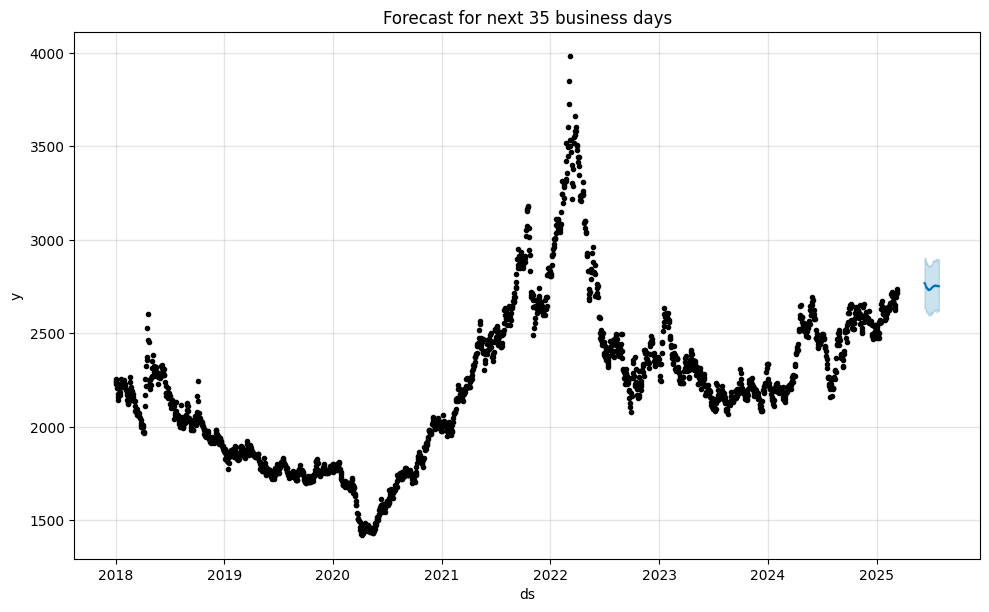

<Figure size 600x600 with 0 Axes>

In [ ]:
from pandas.tseries.offsets import BDay

future_dates = pd.date_range(start=Al["ds"].max() + BDay(1), periods=35, freq=BDay())
future_df = pd.DataFrame({"ds": future_dates})

# Forecast
forecast = model.predict(future_df)

# Plot forecast
model.plot(forecast)
plt.title("Forecast for next 35 business days")
plt.show()

In [11]:
forecast.to_csv('forecast.csv', index=False)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-06-11,2764.237945,2631.148581,2894.775534,2764.237945,2764.237945,4.763933,4.763933,4.763933,-5.564946,-5.564946,-5.564946,10.328879,10.328879,10.328879,0.0,0.0,0.0,2769.001879
1,2025-06-12,2765.223433,2625.092480,2914.526625,2765.223433,2765.223433,2.840662,2.840662,2.840662,-2.493679,-2.493679,-2.493679,5.334341,5.334341,5.334341,0.0,0.0,0.0,2768.064095
2,2025-06-13,2766.208920,2629.441023,2893.937229,2766.208920,2766.208920,-2.250849,-2.250849,-2.250849,-2.580958,-2.580958,-2.580958,0.330109,0.330109,0.330109,0.0,0.0,0.0,2763.958071
3,2025-06-16,2769.165381,2612.055382,2873.753241,2769.165381,2769.165381,-18.634767,-18.634767,-18.634767,-4.525282,-4.525282,-4.525282,-14.109486,-14.109486,-14.109486,0.0,0.0,0.0,2750.530614
4,2025-06-17,2770.150868,2612.652312,2877.319254,2770.150868,2770.150868,-24.688372,-24.688372,-24.688372,-6.149071,-6.149071,-6.149071,-18.539301,-18.539301,-18.539301,0.0,0.0,0.0,2745.462496
